In [35]:
import pandas as pd
import numpy as np
import mlflow
import sklearn.metrics
import sklearn.neighbors
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
data_positions = pd.read_parquet("data/gold/telemetry_pos_Y2026R03.parquet")

In [3]:
mlflow_runs = mlflow.search_runs(experiment_names=["formula_one_circuit_map"])
mlflow_runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.mae-time-x,metrics.rmse-distance-z,metrics.rmse-time-x,metrics.mae-distance-x,...,metrics.rmse-time-y,params.predict_size,params.max_degree,tags.mlflow.user,tags.mlflow.runName,tags.run_id,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.session_ids
0,8abaf2332365463b83a4b89d349065be,1,FINISHED,/mnt/e/Coding/formula_one_data_analysis/mlruns...,2026-04-05 22:46:10.153000+00:00,2026-04-05 22:49:46.053000+00:00,57.035793,0.165187,82.914953,0.410269,...,71.477888,100000,100,tiagobbatalhao,329a36c5-e04b-4d7b-8791-78ccc8613da6,329a36c5-e04b-4d7b-8791-78ccc8613da6,LOCAL,src/run_circuit_map.py,e8313f0e58642894a4f13e198a6ce77b33243672,Y2026R03S1_Y2026R03S2_Y2026R03S3_Y2026R03S4_Y2...


In [4]:
path = mlflow.artifacts.download_artifacts(artifact_uri=mlflow_runs.iloc[0]["artifact_uri"] + "/result.parquet")
data_map = pd.read_parquet(path)

In [5]:
data_map

,encoding,coordinate_x,coordinate_y,coordinate_z,derivative_x,derivative_y,derivative_z,total_distance_m,distance_m
0,0.00000,1621.419861,-556.635952,742.698912,37744.662034,-43531.445025,-1502.566814,5761.06225,0.000000
1,0.00001,1621.797299,-557.071273,742.683888,37742.995941,-43532.701870,-1502.220580,5761.06225,0.057616
2,0.00002,1622.174721,-557.506607,742.668868,37741.319362,-43533.967551,-1501.877711,5761.06225,0.115232
3,0.00003,1622.552126,-557.941953,742.653851,37739.632378,-43535.242007,-1501.538220,5761.06225,0.172848
4,0.00004,1622.929514,-558.377311,742.638837,37737.935067,-43536.525177,-1501.202118,5761.06225,0.230464
...,...,...,...,...,...,...,...,...,...
99995,0.99995,1619.532423,-554.459535,742.774085,37752.832470,-43525.295464,-1504.348038,5761.06225,5760.774166
99996,0.99996,1619.909943,-554.894794,742.759043,37751.219980,-43526.507221,-1503.985161,5761.06225,5760.831783
99997,0.99997,1620.287447,-555.330065,742.744005,37749.596614,-43527.728116,-1503.625587,5761.06225,5760.889400
99998,0.99998,1620.664935,-555.765348,742.728970,37747.962449,-43528.958088,-1503.269330,5761.06225,5760.947017


In [6]:
data_positions

,year,session_id,driver_number,lap_number,timestamp,timing_from_session,timing_from_lap,track_status,coordinate_x,coordinate_y,coordinate_z,position_status
0,2026,Y2026R03S1,1,1,2026-03-27 02:30:30.418000+00:00,906.033,0.006,6,3704.0,-3212.0,0.0,OnTrack
1,2026,Y2026R03S1,1,1,2026-03-27 02:30:30.598000+00:00,906.213,0.186,6,3708.0,-3217.0,0.0,OnTrack
2,2026,Y2026R03S1,1,1,2026-03-27 02:30:30.778000+00:00,906.393,0.366,6,3713.0,-3222.0,0.0,OnTrack
3,2026,Y2026R03S1,1,1,2026-03-27 02:30:31.118000+00:00,906.733,0.706,6,3719.0,-3230.0,0.0,OnTrack
4,2026,Y2026R03S1,1,1,2026-03-27 02:30:31.418000+00:00,907.033,1.006,6,3729.0,-3240.0,0.0,OnTrack
...,...,...,...,...,...,...,...,...,...,...,...,...
1538062,2026,Y2026R03S5,87,21,2026-03-29 05:49:15.745000+00:00,5938.377,149.043,4,-11939.0,2476.0,944.0,OnTrack
1538063,2026,Y2026R03S5,87,21,2026-03-29 05:49:15.965000+00:00,5938.597,149.263,4,-11939.0,2476.0,944.0,OnTrack
1538064,2026,Y2026R03S5,87,21,2026-03-29 05:49:16.245000+00:00,5938.877,149.543,4,-11939.0,2476.0,944.0,OnTrack
1538065,2026,Y2026R03S5,87,21,2026-03-29 05:49:16.425000+00:00,5939.057,149.723,4,-11939.0,2476.0,944.0,OnTrack


In [40]:
find_neighbours = sklearn.neighbors.NearestNeighbors(n_neighbors=10).fit(
    data_map[["coordinate_x", "coordinate_y"]].values
)

In [41]:
aux = find_neighbours.kneighbors(data_positions[["coordinate_x", "coordinate_y"]].values)

In [ ]:

aux[1][:, 0]

array([ 5853,  5864,  5876, ..., 64143, 64143, 64143], shape=(1538067,))

In [45]:
data_positions["idx"] = aux[1][:, 0]
data_positions = data_positions.merge(
    data_map.assign(idx=lambda df: range(len(df)))[["idx", "encoding", "distance_m"]]
)

In [46]:
for i in range(aux[1].shape[1]):
    data_positions[f"closest_{i:02d}"] = aux[1][:, i]


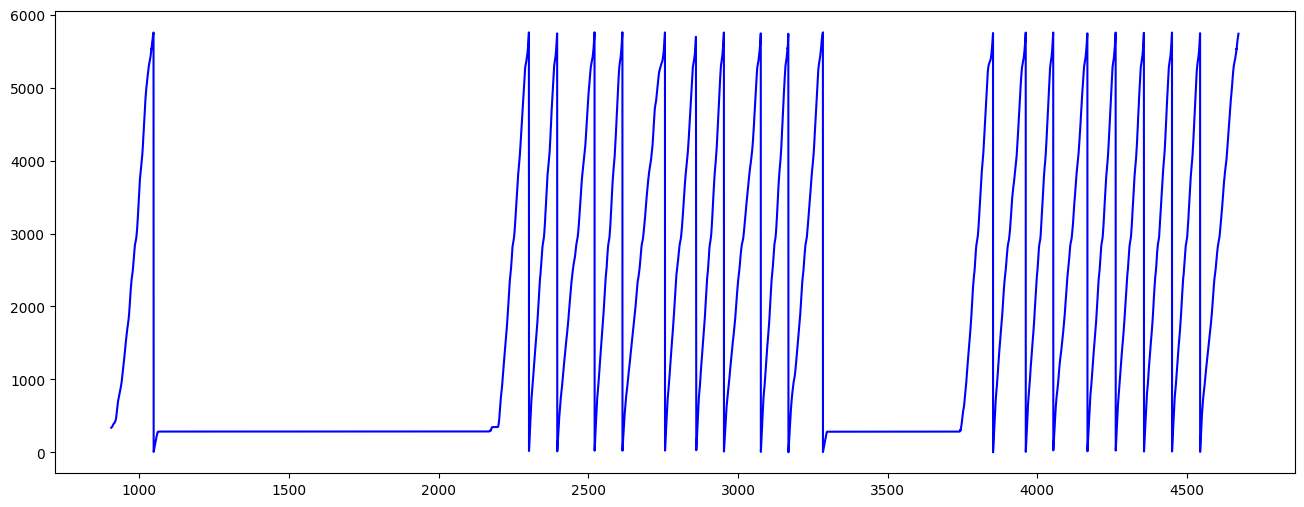

In [18]:
example = data_positions[
    (data_positions["session_id"] == "Y2026R03S1")
    & (data_positions["driver_number"] == 1)
]
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(
    example["timing_from_session"],
    example["distance_m"],
    "b-"
)

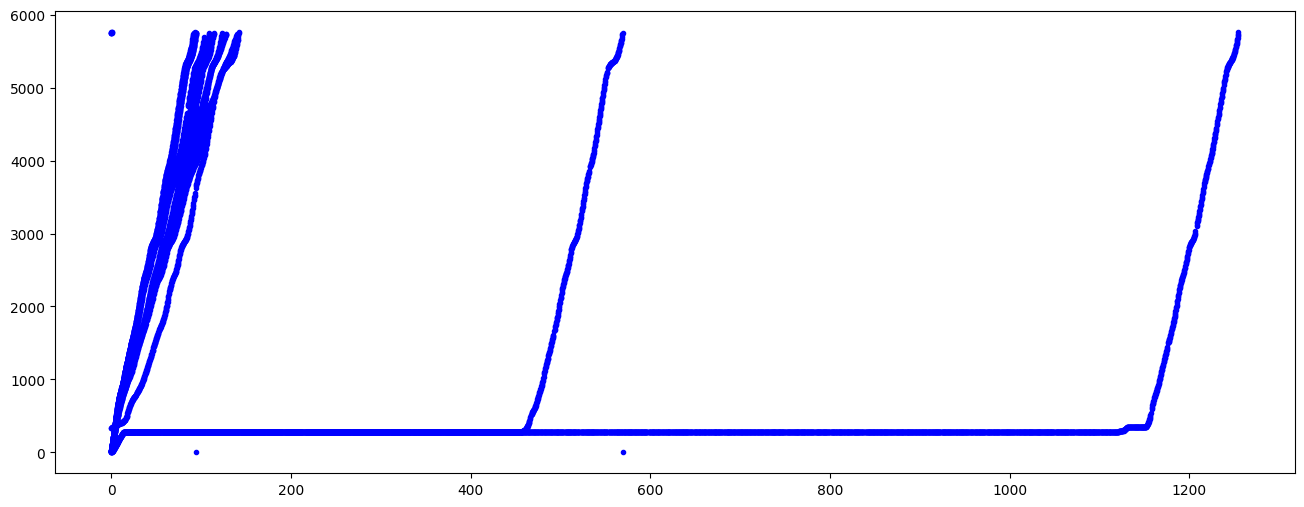

In [20]:
example = data_positions[
    (data_positions["session_id"] == "Y2026R03S1")
    & (data_positions["driver_number"] == 1)
]
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(
    example["timing_from_lap"],
    example["distance_m"],
    "b."
)

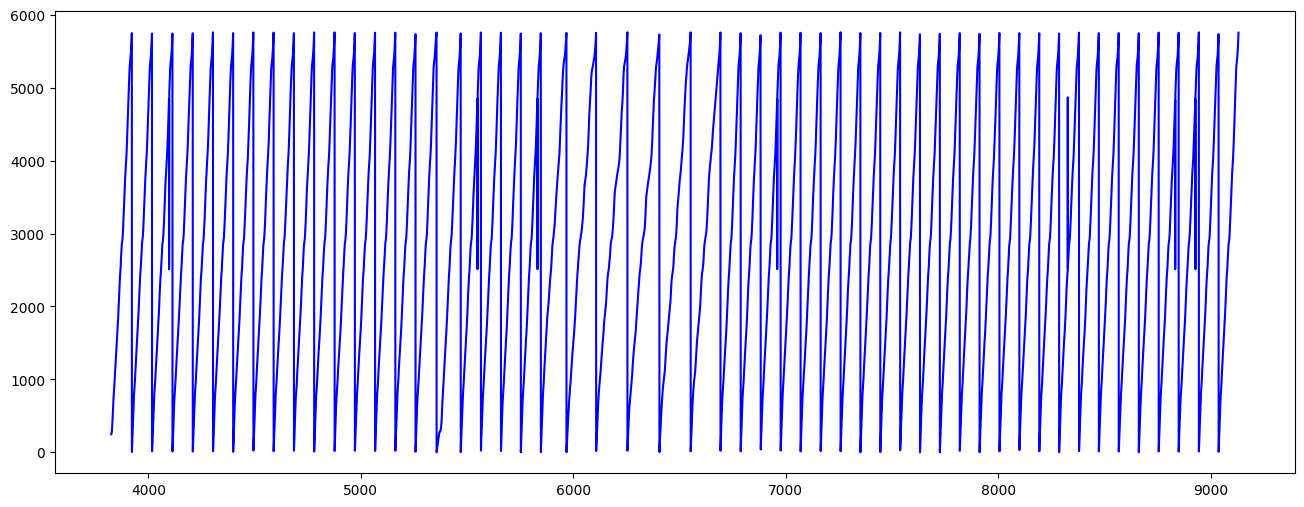

In [23]:
example = data_positions[
    (data_positions["session_id"] == "Y2026R03S5")
    & (data_positions["driver_number"] == 1)
]
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(
    example["timing_from_session"],
    example["distance_m"],
    "b-"
)

In [47]:
example = data_positions[
    (data_positions["session_id"] == "Y2026R03S5")
    & (data_positions["driver_number"] == 1)
]
plot_data = [
    go.Scatter(
        x=example["timing_from_session"],
        y=example["distance_m"],
        mode="lines+markers",
    )
]
plot_layout = dict(
    width=1200,
    height=700,
)
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [48]:
example = example.sort_values(by=["timing_from_session"])
example["previous_x"] = example["coordinate_x"].shift(1)
example["previous_y"] = example["coordinate_y"].shift(1)
example["displacement"] = np.sqrt((example["previous_x"]-example["coordinate_x"])**2 + (example["previous_y"]-example["coordinate_y"])**2)

In [49]:
example["displacement"].describe()

count    20187.000000
mean       151.376340
std         85.799883
min          0.000000
25%         91.706052
50%        137.568165
75%        193.538110
max       1008.452775
Name: displacement, dtype: float64

In [50]:
plot_data = [
    go.Scatter(
        x=example["timing_from_session"],
        y=example["distance_m"],
        mode="lines+markers",
    ),
    go.Scatter(
        x=example["timing_from_session"],
        y=example["displacement"] / 10.0,
        mode="lines+markers",
    ),
]
plot_layout = dict(
    width=1200,
    height=700,
)
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [54]:
example[example["timing_from_session"]>=6960].iloc[:10].filter(regex="closest|distance_m|coordinate")

,coordinate_x,coordinate_y,coordinate_z,distance_m,closest_00,closest_01,closest_02,closest_03,closest_04,closest_05,closest_06,closest_07,closest_08,closest_09
1124942,-6086.0,-1551.0,863.0,4839.996048,84010,84009,84011,84008,84012,84007,84013,84006,84014,84005
1124943,-5823.0,-1640.0,800.0,2511.651265,43596,43597,43595,43598,43594,84492,84491,84493,43599,43593
1124944,-5517.0,-1737.0,864.0,4899.800760,85048,85049,85047,85050,85046,85051,85045,85052,85044,85053
1124945,-5441.0,-1750.0,864.0,4907.499742,85182,85181,85183,85180,85184,85179,85185,85178,85186,85177
1124946,-5299.0,-1756.0,864.0,4921.621283,85427,85428,85426,85429,85425,85430,85424,85431,85423,85432
1124947,-5018.0,-1696.0,864.0,4950.278037,85924,85925,85923,85926,85922,85927,85921,85928,85920,85929
1124948,-4839.0,-1632.0,865.0,4969.283935,86255,86256,86254,86257,86253,86258,86252,86259,86251,86260
1124949,-4701.0,-1577.0,866.0,4984.113285,86511,86512,86510,86513,86509,86514,86508,86515,86507,86516
1124950,-4464.0,-1468.0,868.0,5010.225355,86965,86964,86966,86963,86967,86962,86968,86961,86969,86960
1124951,-4288.0,-1371.0,871.0,5030.304460,87314,87315,87313,87316,87312,87317,87311,87318,87310,87319


In [59]:
total = data_map["total_distance_m"].values[0]
to_fix = example["distance_m"] / total

In [75]:
# def apply_fix(vec):
#     THRESHOLD_NEAR_ONE = 0.95
#     correction = np.zeros_like(vec)
#     if vec[0] > THRESHOLD_NEAR_ONE:
#         correction -= 1.0
#     elif vec[0] < - THRESHOLD_NEAR_ONE:
#         correction += 1.0
#     diff = np.diff(vec)
#     for i in range(len(diff)):
#         if diff[i] > THRESHOLD_NEAR_ONE:
#             correction[i:] -= 1.0
#         elif diff[i] < - THRESHOLD_NEAR_ONE:
#             correction[i:] += 1.0
#     return correction
            
def apply_fix(vec):
    THRESHOLD_NEAR_ONE = 0.95
    correction = np.zeros_like(vec)
    if vec[0] > THRESHOLD_NEAR_ONE:
        correction -= 1.0
    elif vec[0] < - THRESHOLD_NEAR_ONE:
        correction += 1.0
    for i in range(1, len(vec)):
        diff = vec[i] - vec[i-1]
        if diff > + THRESHOLD_NEAR_ONE:
            correction[i:] -= 1.0
        if diff < - THRESHOLD_NEAR_ONE:
            correction[i:] += 1.0
    return correction

In [76]:
diff = np.diff(to_fix)
diff.shape, to_fix.shape

((20187,), (20188,))

In [77]:
pd.Series(diff).describe(percentiles=[0.01, 0.99])

count    20187.000000
mean         0.000047
std          0.051768
min         -0.999310
1%           0.000375
50%          0.002376
99%          0.007041
max          0.415331
dtype: float64

In [78]:
xx = example["timing_from_session"].iloc[:5000]
yy = example["distance_m"].iloc[:5000]

corr = apply_fix(yy.values / total)
plot_data = [
    go.Scatter(x=xx, y=yy, mode="lines+markers"),
    go.Scatter(x=xx, y=yy + corr*total, mode="lines+markers"),
]
plot_layout = dict(
    width=1200,
    height=700,
)
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

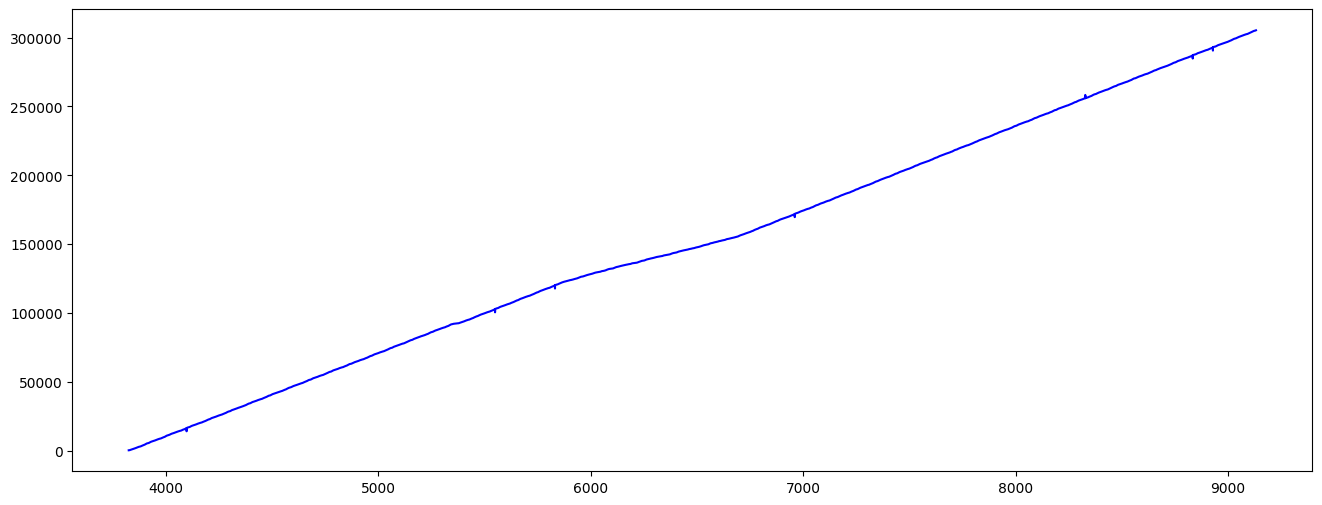

In [80]:
xx = example["timing_from_session"].iloc[:]
yy = example["distance_m"].iloc[:]
corr = apply_fix(yy.values / total)
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(xx, yy + corr * total, 'b-')

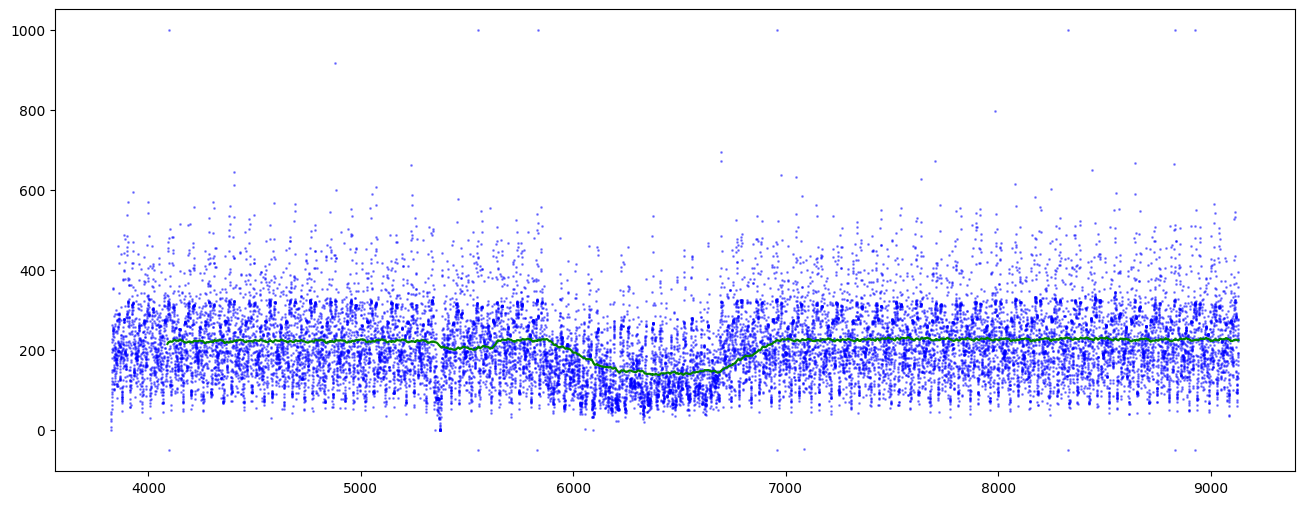

In [103]:
xx = example["timing_from_session"].iloc[:]
yy = example["distance_m"].iloc[:]
corr = apply_fix(yy.values / total)
speed = ((np.diff(yy + corr * total) / np.diff(xx)) * 3.6).clip(min=-50, max=+1000)
fig, ax = plt.subplots(figsize=(16,6))
ax.scatter(xx[1:], speed, color='b', s=1, alpha=0.4)
ax.plot(xx[1:], pd.Series(speed).rolling(1000).mean(), 'g-')

In [84]:
pd.Series(diff).describe(percentiles=[0.01, 0.99])

count    20187.000000
mean        15.112946
std         62.607642
min      -2339.102291
1%           2.547195
50%         13.720759
99%         40.601411
max       2392.745359
dtype: float64

<Axes: ylabel='Frequency'>

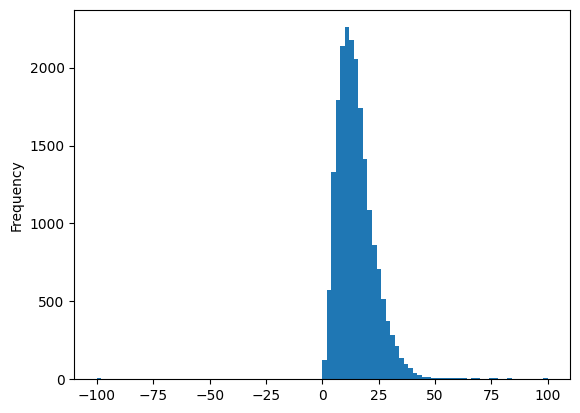

In [85]:
pd.Series(diff).clip(upper=100, lower=-100).plot.hist(bins=100)

In [86]:
diff[diff>100]

array([2392.74535868, 2387.51747641, 2378.66047796, 2388.14949499,
       2367.95922978,  100.89631744, 2369.49476513, 2366.32073938])

In [87]:
diff[diff<-100]

array([-2326.8494054 , -2339.10229053, -2336.97298044, -2328.3447822 ,
       -2337.66951845, -2313.95632121, -2333.80875875])